In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline

In [2]:
def simple_moving_average(x, n):
    x_series = pd.Series(x)
    windows = x_series.rolling(window=n)
    x_avg = windows.mean()
    return x_avg[n-1:]

In [3]:
def resample_to_n(y, n=2000):
    """
    Resample a 1D array to exactly n points using linear interpolation.
    Keeps endpoints; changes only the number of samples.
    """
    y = np.asarray(y, dtype=float).ravel()
    if y.size == 0:
        return np.empty((n,), dtype=float)

    x_old = np.linspace(0.0, 1.0, y.size, endpoint=True)
    x_new = np.linspace(0.0, 1.0, n, endpoint=True)
    return np.interp(x_new, x_old, y)

Compression

In [4]:
simulation_compression = pd.read_excel('Testing_protocol_paper_results.xlsx', sheet_name='Compression', header=None, na_filter=True)

In [5]:
strain_compression_pf = simulation_compression.iloc[1:, 2].to_numpy().astype(float)
stress_compression_pf = simulation_compression.iloc[1:, 3].to_numpy().astype(float)
strain_compression_exp1 = simulation_compression.iloc[2:, 5].to_numpy().astype(float)
stress_compression_exp1 = simulation_compression.iloc[2:, 6].to_numpy().astype(float)
strain_compression_exp2 = simulation_compression.iloc[2:, 8].to_numpy().astype(float)
stress_compression_exp2 = simulation_compression.iloc[2:, 9].to_numpy().astype(float)
strain_compression_exp3 = simulation_compression.iloc[2:, 11].to_numpy().astype(float)
stress_compression_exp3 = simulation_compression.iloc[2:, 12].to_numpy().astype(float)

In [6]:
strain_compression_pf_smoothed = simple_moving_average(strain_compression_pf, 10)
stress_compression_pf_smoothed = simple_moving_average(stress_compression_pf, 10)

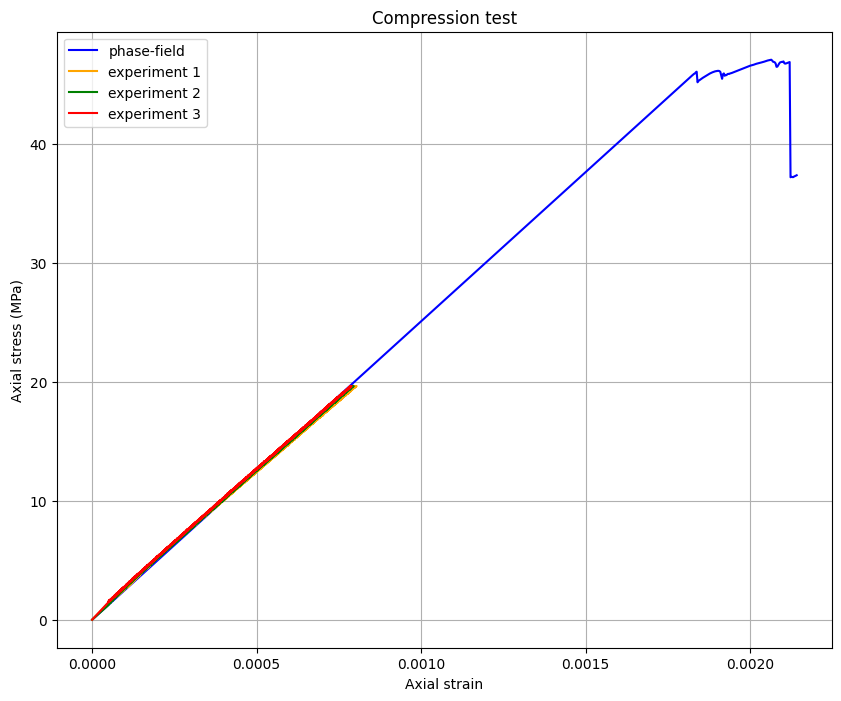

In [7]:
plt.figure(figsize=(10, 8))
plt.plot(strain_compression_pf, stress_compression_pf, label='phase-field', color='blue')
# plt.plot(strain_compression_pf_smoothed, stress_compression_pf_smoothed, label='phase-field', color='blue')
plt.plot(strain_compression_exp1, stress_compression_exp1, label='experiment 1', color='orange')
plt.plot(strain_compression_exp2, stress_compression_exp2, label='experiment 2', color='green')
plt.plot(strain_compression_exp3, stress_compression_exp3, label='experiment 3', color='red')
plt.xlabel('Axial strain')
plt.ylabel('Axial stress (MPa)')
plt.title('Compression test')
plt.legend()
plt.grid()

In [8]:
# strain_compression_exp1_2000 = resample_to_n(strain_compression_exp1, n=2000)
# stress_compression_exp1_2000 = resample_to_n(stress_compression_exp1, n=2000)
# strain_compression_exp2_2000 = resample_to_n(strain_compression_exp2, n=2000)
# stress_compression_exp2_2000 = resample_to_n(stress_compression_exp2, n=2000)
# strain_compression_exp3_2000 = resample_to_n(strain_compression_exp3, n=2000)
# stress_compression_exp3_2000 = resample_to_n(stress_compression_exp3, n=2000)

# # Save compression test data to an Excel file
# data_to_save_compression = {
#     "compression_exp1": (strain_compression_exp1_2000, stress_compression_exp1_2000),
#     "compression_exp2": (strain_compression_exp2_2000, stress_compression_exp2_2000),
#     "compression_exp3": (strain_compression_exp3_2000, stress_compression_exp3_2000),
# }

# out_path_compression = "compression_test_corrected_curves.xlsx"

# with pd.ExcelWriter(out_path_compression, engine="xlsxwriter") as writer:
#     for sheet, (eps, S) in data_to_save_compression.items():
#         df_out = pd.DataFrame({"eps": np.asarray(eps, dtype=float), "S_MPa": np.asarray(S, dtype=float)})
#         df_out.to_excel(writer, sheet_name=sheet, index=False)

# print(f"Saved to {out_path_compression}")


Brazilian

In [9]:
simulation_brazilian = pd.read_excel('Testing_protocol_paper_results.xlsx', sheet_name='Brazilian', header=None, na_filter=True)

In [10]:
d_brazilian_pf = 150*simulation_brazilian.iloc[2:224, 0].to_numpy().astype(float)
P_brazilian_pf = np.pi*75*50/1000*simulation_brazilian.iloc[2:224, 1].to_numpy().astype(float)

In [11]:
d_brazilian_experiment1 = 152.4*simulation_brazilian.iloc[2:27183, 5].to_numpy().astype(float)
P_brazilian_experiment1 = np.pi*76.2*51.7/1000*simulation_brazilian.iloc[2:27183, 6].to_numpy().astype(float)
d_brazilian_experiment2 = 152.4*simulation_brazilian.iloc[2:20587, 8].to_numpy().astype(float)
P_brazilian_experiment2 = np.pi*76.2*51.1/1000*simulation_brazilian.iloc[2:20587, 9].to_numpy().astype(float)
d_brazilian_experiment3 = 152.4*simulation_brazilian.iloc[2:20546, 11].to_numpy().astype(float)
P_brazilian_experiment3 = np.pi*76.2*52/1000*simulation_brazilian.iloc[2:20546, 12].to_numpy().astype(float)
d_brazilian_experiment4 = 152.4*simulation_brazilian.iloc[2:20605, 14].to_numpy().astype(float)
P_brazilian_experiment4 = np.pi*76.2*51.3/1000*simulation_brazilian.iloc[2:20605, 15].to_numpy().astype(float)

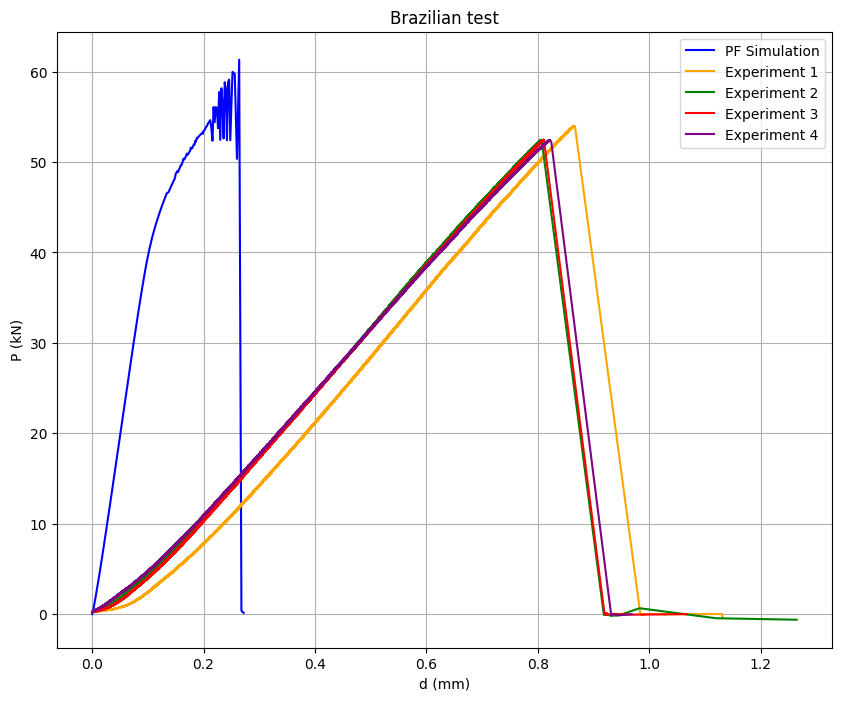

In [12]:
plt.figure(figsize=(10, 8))
plt.plot(d_brazilian_pf, P_brazilian_pf, label='PF Simulation', color='blue')
plt.plot(d_brazilian_experiment1, P_brazilian_experiment1, label='Experiment 1', color='orange')
plt.plot(d_brazilian_experiment2, P_brazilian_experiment2, label='Experiment 2', color='green')
plt.plot(d_brazilian_experiment3, P_brazilian_experiment3, label='Experiment 3', color='red')
plt.plot(d_brazilian_experiment4, P_brazilian_experiment4, label='Experiment 4', color='purple')
plt.xlabel('d (mm)')
plt.ylabel('P (kN)')
plt.title('Brazilian test')
plt.legend()
plt.grid()
# plt.xlim(0, 0.1)
# plt.ylim(0, 10)

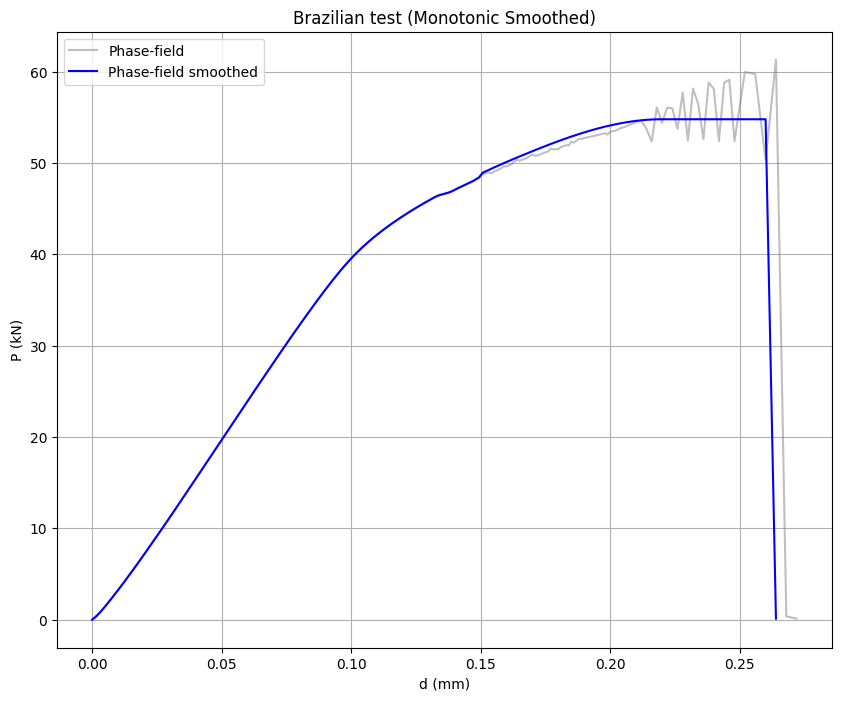

In [13]:
P_brazilian_pf_smoothed = simple_moving_average(P_brazilian_pf, 5).to_numpy()
d_brazilian_pf_smoothed = simple_moving_average(d_brazilian_pf, 5).to_numpy()
P_brazilian_pf_smoothed = np.array([0, *P_brazilian_pf_smoothed])
d_brazilian_pf_smoothed = np.array([0, *d_brazilian_pf_smoothed])

# 1) Clean + restrict domain
d_brazilian_pf_smoothed = np.asarray(d_brazilian_pf_smoothed, dtype=float)
P_brazilian_pf_smoothed = np.asarray(P_brazilian_pf_smoothed, dtype=float)

mask = (
    np.isfinite(d_brazilian_pf_smoothed) & np.isfinite(P_brazilian_pf_smoothed) &
    (d_brazilian_pf_smoothed >= 0.) & (d_brazilian_pf_smoothed <= np.max(d_brazilian_pf_smoothed))
)

d_brazilian_pf_smoothed = d_brazilian_pf_smoothed[mask]
P_brazilian_pf_smoothed = P_brazilian_pf_smoothed[mask]

# Guard against duplicate x values (required for spline fit)
order = np.argsort(d_brazilian_pf_smoothed)
d_brazilian_pf_smoothed = d_brazilian_pf_smoothed[order]
P_brazilian_pf_smoothed = P_brazilian_pf_smoothed[order]
d_brazilian_pf_smoothed, idx = np.unique(d_brazilian_pf_smoothed, return_index=True)
P_brazilian_pf_smoothed = P_brazilian_pf_smoothed[idx]

# 2) Fit smoothing spline (s chosen from noise level)
# Larger s => smoother curve. This heuristic usually works for experimental-like data.
s = 0.007 * len(d_brazilian_pf_smoothed) * np.nanvar(P_brazilian_pf_smoothed)
spl = UnivariateSpline(d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, s=s)

# 3) Evaluate interpolation + slope on a uniform grid
for i, d in enumerate(d_brazilian_pf_smoothed):
    if d < 0.15:
        P_brazilian_pf_smoothed[i] = P_brazilian_pf_smoothed[i]
    else:
        P_brazilian_pf_smoothed[i] = spl(d)

# Enforce non-decreasing by replacing any decrease with previous value
for i in range(1, len(P_brazilian_pf_smoothed)):
    if P_brazilian_pf_smoothed[i] < P_brazilian_pf_smoothed[i-1]:
        P_brazilian_pf_smoothed[i] = P_brazilian_pf_smoothed[i-1]

P_brazilian_pf_smoothed[-1] = P_brazilian_pf[-1]  # Ensure last point matches original data

plt.figure(figsize=(10, 8))
plt.plot(d_brazilian_pf, P_brazilian_pf, label='Phase-field', color='gray', alpha=0.5)
plt.plot(d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, label='Phase-field smoothed', color='blue')
# plt.plot(d_brazilian_experiment1, P_brazilian_experiment1, label='Experiment 1', color='orange')
# plt.plot(d_brazilian_experiment2, P_brazilian_experiment2, label='Experiment 2', color='green')
# plt.plot(d_brazilian_experiment3, P_brazilian_experiment3, label='Experiment 3', color='red')
# plt.plot(d_brazilian_experiment4, P_brazilian_experiment4, label='Experiment 4', color='purple')
plt.xlabel('d (mm)')
plt.ylabel('P (kN)')
plt.title('Brazilian test (Monotonic Smoothed)')
plt.legend()
plt.grid()

In [14]:
max(P_brazilian_pf_smoothed)

np.float64(54.79385930188202)

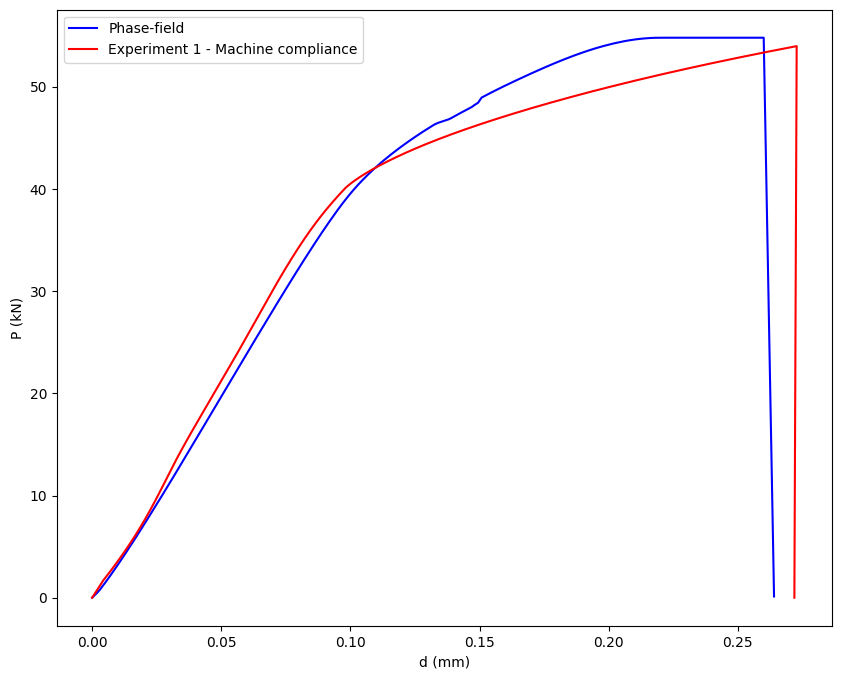

In [15]:
def compliance(d_exp, P_exp, d_pf, P_pf, pow, rand_slope):
    d_pf_comp = np.asarray(d_pf[:-1], dtype=float)
    P_pf_comp = np.asarray(P_pf[:-1], dtype=float)
    d_pf_comp = d_pf[:np.where(P_pf == P_pf.max())[0][0]]
    P_pf_comp = P_pf[:np.where(P_pf == P_pf.max())[0][0]]
    d_exp_comp = np.asarray(d_exp, dtype=float)
    P_exp_comp = np.asarray(P_exp, dtype=float)
    mask = np.isfinite(d_exp_comp) & np.isfinite(P_exp_comp) 
    d_exp_comp = d_exp_comp[mask]
    P_exp_comp = P_exp_comp[mask]
    d_exp_comp = d_exp[:np.where(P_exp == P_exp.max())[0][0]]
    P_exp_comp = P_exp[:np.where(P_exp == P_exp.max())[0][0]]

    order = np.argsort(P_exp_comp)
    d_exp_comp = d_exp_comp[order]
    P_exp_comp = P_exp_comp[order]
    P_exp_comp, idx = np.unique(P_exp_comp, return_index=True)
    d_exp_comp = d_exp_comp[idx]

    s = 0.00001 * len(P_exp_comp) * np.nanvar(d_exp_comp)
    spl_exp = UnivariateSpline(P_exp_comp, d_exp_comp, s=s)

    order = np.argsort(P_pf_comp)
    d_pf_comp = d_pf_comp[order]
    P_pf_comp = P_pf_comp[order]
    P_pf_comp, idx = np.unique(P_pf_comp, return_index=True)
    d_pf_comp = d_pf_comp[idx]

    s = 0.0001 * len(P_pf_comp) * np.nanvar(d_pf_comp)
    spl_pf = UnivariateSpline(P_pf_comp, d_pf_comp, s=s)

    P_machine = np.linspace(0, 40, 100)
    d_machine = spl_exp(P_machine) - spl_pf(P_machine)

    order = np.argsort(P_machine)
    P_machine = P_machine[order]
    d_machine = d_machine[order]
    P_machine, idx = np.unique(P_machine, return_index=True)
    d_machine = d_machine[idx]

    s = 0.00001 * len(P_machine) * np.nanvar(d_machine)
    spl_machine = UnivariateSpline(P_machine, d_machine, s=s)

    # rand_slope = np.random.uniform(0.95, 1.05)
    d_exp_actual = np.zeros_like(d_exp_comp)
    for i, P in enumerate(P_exp_comp):
        if P < 40:
            d_exp_actual[i] = spl_exp(P) - spl_machine(P)*rand_slope
        else:
            d_exp_actual[i] = spl_exp(P) - spl_machine(P)*((P-40)**pow/(P_exp_comp.max()-40)*(0.97-1)+1)*rand_slope  # Extrapolate beyond 40 kN
    # d_exp_actual = spl_exp(P_exp_comp) - spl_machine(P_exp_comp)
    d_exp_actual = np.array([0, *d_exp_actual, d_exp_actual[-1] + (d_exp_comp[-1] - d_exp_comp[-2])])  # Extrapolate last point
    P_exp_actual = P_exp_comp
    P_exp_actual = np.array([0, *P_exp_actual, 0])  # Extrapolate last point
    return spl_machine, spl_exp, d_exp_actual, P_exp_actual

spl_machine, spl_exp, d_exp_actual, P_exp_actual = compliance(d_brazilian_experiment1[2000:], P_brazilian_experiment1[2000:], d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, 1.6, 1.01)

plt.figure(figsize=(10, 8))
plt.plot(d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, label='Phase-field', color='blue')
# plt.plot(d_brazilian_experiment1, P_brazilian_experiment1, label='Experiment 1', color='orange')
plt.plot(d_exp_actual, P_exp_actual, label='Experiment 1 - Machine compliance', color='red')
# plt.plot(spl_exp(np.linspace(0,30,100))-spl_machine(np.linspace(0, 30, 100)), np.linspace(0, 30, 100), label='Machine compliance curve', color='red')
# plt.plot(np.linspace(0,1,10), P_brazilian_experiment1.max()*np.ones_like(np.linspace(0,1,10)), label='Max load', color='red', linestyle=':')
plt.xlabel('d (mm)')
plt.ylabel('P (kN)')
plt.legend()

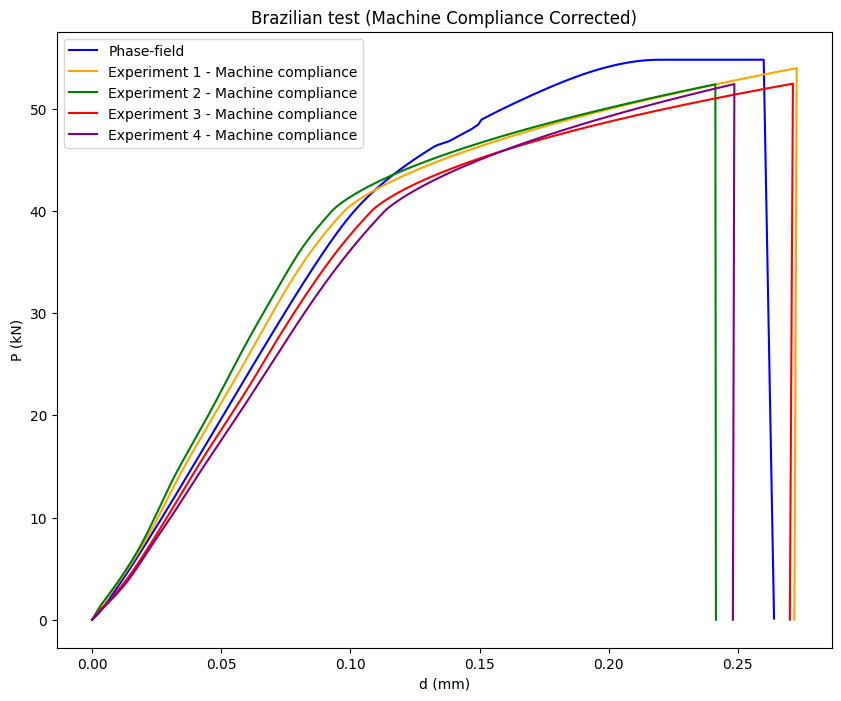

In [16]:
spl_machine1, spl_exp1, d_brazilian_exp1_actual, P_brazilian_exp1_actual = compliance(d_brazilian_experiment1[2000:], P_brazilian_experiment1[2000:], d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, 1.6, 1.01)
spl_machine2, spl_exp2, d_brazilian_exp2_actual, P_brazilian_exp2_actual = compliance(d_brazilian_experiment2[1000:], P_brazilian_experiment2[1000:], d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, 1.6, 1.02)
spl_machine3, spl_exp3, d_brazilian_exp3_actual, P_brazilian_exp3_actual = compliance(d_brazilian_experiment3[1000:], P_brazilian_experiment3[1000:], d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, 1.65, 0.99)
spl_machine4, spl_exp4, d_brazilian_exp4_actual, P_brazilian_exp4_actual = compliance(d_brazilian_experiment4[1000:], P_brazilian_experiment4[1000:], d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, 1.5, 0.98)

plt.figure(figsize=(10, 8))
plt.plot(d_brazilian_pf_smoothed, P_brazilian_pf_smoothed, label='Phase-field', color='blue')
plt.plot(d_brazilian_exp1_actual, P_brazilian_exp1_actual, label='Experiment 1 - Machine compliance', color='orange')
# plt.plot(d_brazilian_experiment1, P_brazilian_experiment1, label='Experiment 1', color='orange', alpha=0.5)
plt.plot(d_brazilian_exp2_actual, P_brazilian_exp2_actual, label='Experiment 2 - Machine compliance', color='green')
plt.plot(d_brazilian_exp3_actual, P_brazilian_exp3_actual, label='Experiment 3 - Machine compliance', color='red')
plt.plot(d_brazilian_exp4_actual, P_brazilian_exp4_actual, label='Experiment 4 - Machine compliance', color='purple')
plt.xlabel('d (mm)')
plt.ylabel('P (kN)')
plt.title('Brazilian test (Machine Compliance Corrected)')
plt.legend()

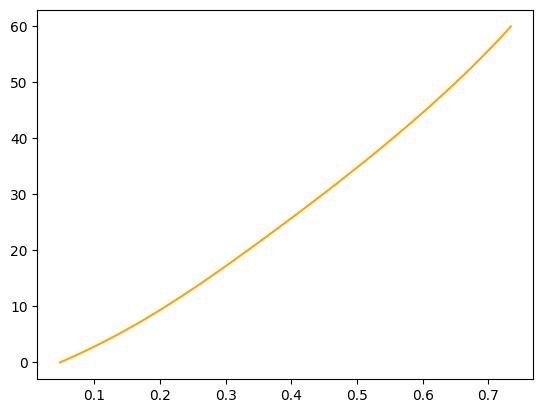

In [17]:
plt.plot(spl_machine1(np.linspace(0,60,100)), np.linspace(0, 60, 100), label='Machine compliance curve', color='orange')

In [18]:
# d_brazilian_exp1_actual_2000 = resample_to_n(d_brazilian_exp1_actual, n=2000)
# P_brazilian_exp1_actual_2000 = resample_to_n(P_brazilian_exp1_actual, n=2000)
# d_brazilian_exp2_actual_2000 = resample_to_n(d_brazilian_exp2_actual, n=2000)
# P_brazilian_exp2_actual_2000 = resample_to_n(P_brazilian_exp2_actual, n=2000)
# d_brazilian_exp3_actual_2000 = resample_to_n(d_brazilian_exp3_actual, n=2000)
# P_brazilian_exp3_actual_2000 = resample_to_n(P_brazilian_exp3_actual, n=2000)
# d_brazilian_exp4_actual_2000 = resample_to_n(d_brazilian_exp4_actual, n=2000)
# P_brazilian_exp4_actual_2000 = resample_to_n(P_brazilian_exp4_actual, n=2000)

# # Save Brazilian test data to an Excel file
# data_to_save_brazilian = {
#     "brazilian_pf": (d_brazilian_pf_smoothed, P_brazilian_pf_smoothed),
#     "brazilian_exp1": (d_brazilian_exp1_actual_2000, P_brazilian_exp1_actual_2000),
#     "brazilian_exp2": (d_brazilian_exp2_actual_2000, P_brazilian_exp2_actual_2000),
#     "brazilian_exp3": (d_brazilian_exp3_actual_2000, P_brazilian_exp3_actual_2000),
#     "brazilian_exp4": (d_brazilian_exp4_actual_2000, P_brazilian_exp4_actual_2000),
# }

# out_path_brazilian = "brazilian_test_corrected_curves.xlsx"

# with pd.ExcelWriter(out_path_brazilian, engine="xlsxwriter") as writer:
#     for sheet, (d, P) in data_to_save_brazilian.items():
#         df_out = pd.DataFrame({"d_mm": np.asarray(d, dtype=float), "P_kN": np.asarray(P, dtype=float)})
#         df_out.to_excel(writer, sheet_name=sheet, index=False)

# print(f"Saved to {out_path_brazilian}")

In [131]:
P_brazilian_exp1_actual.max(), P_brazilian_exp2_actual.max(), P_brazilian_exp3_actual.max(), P_brazilian_exp4_actual.max()

(np.float64(53.972379893238376),
 np.float64(52.38826067615653),
 np.float64(52.45282473309602),
 np.float64(52.41318950177929))

Wedge

In [19]:
simulation_wedge = pd.read_excel('Testing_protocol_paper_results.xlsx', sheet_name='Wedge', header=None, na_filter=True)

In [20]:
A0 = 75
u_external = simulation_wedge.iloc[2:10, 8].to_numpy().astype(float)
nu = simulation_wedge.iloc[2:10, 9].to_numpy().astype(float)
Y = 25e3*np.ones_like(nu)
Ph1_wedge_nu = simulation_wedge.iloc[2:10, 10].to_numpy().astype(float)*1000
W1_wedge_nu = simulation_wedge.iloc[2:10, 11].to_numpy().astype(float)*1000
Ph2_wedge_nu = simulation_wedge.iloc[2:10, 12].to_numpy().astype(float)*1000
W2_wedge_nu = simulation_wedge.iloc[2:10, 13].to_numpy().astype(float)*1000
G_wedge_nu = simulation_wedge.iloc[2:10, 14].to_numpy().astype(float)/1000

def PUwedge(input, a1, a2, a3):
    nu, Y, u_external = input
    return a1*Y*u_external/(a2 + a3*nu**2)

In [21]:
input_PUwedge = np.vstack((nu, Y, u_external))
popt1, pcov1 = curve_fit(PUwedge, input_PUwedge, Ph1_wedge_nu, p0=[1, 1, 1], bounds=([-10, -10, -10],[10, 10, 10]), method='trf')
popt2, pcov2 = curve_fit(PUwedge, input_PUwedge, Ph2_wedge_nu, p0=[1, 1, 1], bounds=([-10, -10, -10],[10, 10, 10]), method='trf')
print(popt1)
print(popt2)

[ 1.94733335  0.09882748 -0.0478052 ]
[ 1.94962071  0.10450828 -0.04969584]


(0.0, 20.0)

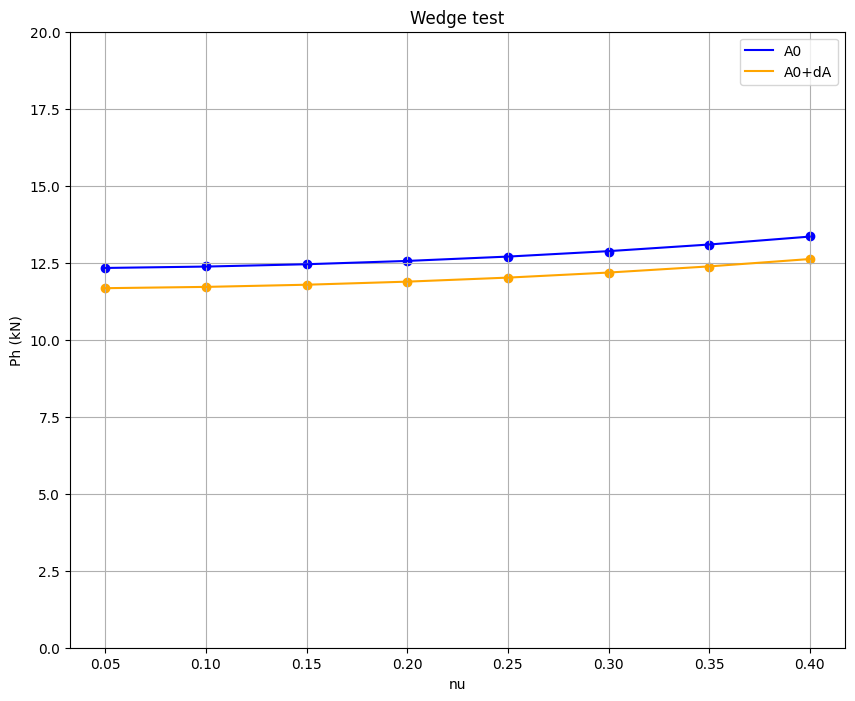

In [22]:
Ph1_wedge_nu_fit = PUwedge(input_PUwedge, *popt1)
Ph2_wedge_nu_fit = PUwedge(input_PUwedge, *popt2)
plt.figure(figsize=(10, 8))
plt.scatter(nu, Ph1_wedge_nu/1000, color='blue')
plt.scatter(nu, Ph2_wedge_nu/1000, color='orange')
plt.plot(nu, Ph1_wedge_nu_fit/1000, color='blue', label='A0')
plt.plot(nu, Ph2_wedge_nu_fit/1000, color='orange', label='A0+dA')
plt.xlabel('nu')
plt.ylabel('Ph (kN)')
plt.title('Wedge test')
plt.legend()
plt.grid()
plt.ylim(0, 20)

(200.0, 400.0)

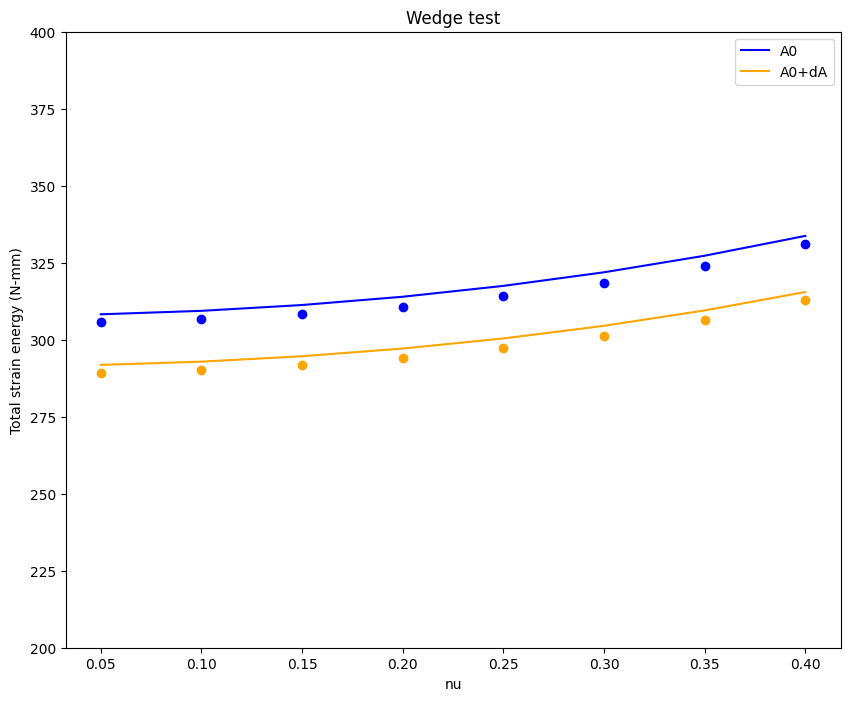

In [23]:
W1_wedge_nu_fit = PUwedge(input_PUwedge, *popt1)*u_external
W2_wedge_nu_fit = PUwedge(input_PUwedge, *popt2)*u_external
plt.figure(figsize=(10, 8))
plt.scatter(nu, W1_wedge_nu, color='blue')
plt.scatter(nu, W2_wedge_nu, color='orange')
plt.plot(nu, W1_wedge_nu_fit, color='blue', label='A0')
plt.plot(nu, W2_wedge_nu_fit, color='orange', label='A0+dA')
plt.xlabel('nu')
plt.ylabel('Total strain energy (N-mm)')
plt.title('Wedge test')
plt.legend()
plt.ylim(200, 400)

In [24]:
def Gwedge(input, a1, a2, a3, a4, a5):
    nu, Y, u_external = input
    return (a1 + a2*nu**2)*Y*u_external**2/(a3 + a4*nu**2 + a5*u_external**2)/A0

In [25]:
input_Gwedge = np.vstack((nu, Y, u_external))
popt_Gwedge, pcov_Gwedge = curve_fit(Gwedge, input_Gwedge, G_wedge_nu, p0=[1, 1, 1, 1, 1], bounds=([-10, -10, -10, -10, -10],[10, 10, 10, 10, 10]), method='trf')
print(popt_Gwedge)

[ 0.1096956  -0.02111468  1.75732102 -1.40552939  1.67138245]


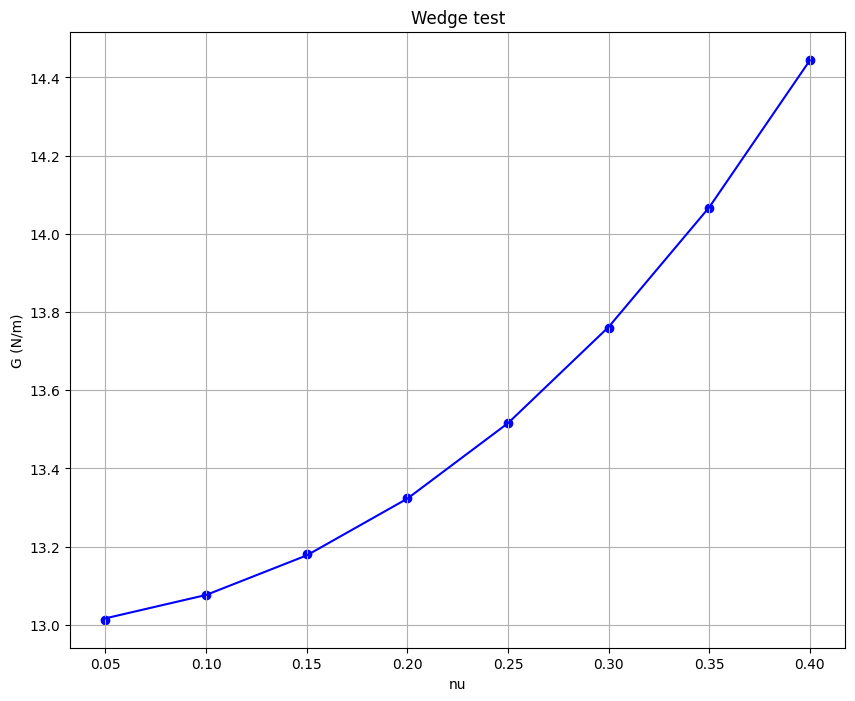

In [26]:
G_wedge_nu_fit = Gwedge(input_Gwedge, *popt_Gwedge)
plt.figure(figsize=(10, 8))
plt.scatter(nu, G_wedge_nu*1000, color='blue')
plt.plot(nu, G_wedge_nu_fit*1000, color='blue', label='Fit')
plt.xlabel('nu')
plt.ylabel('G (N/m)')
plt.title('Wedge test')
# plt.legend()
plt.grid()

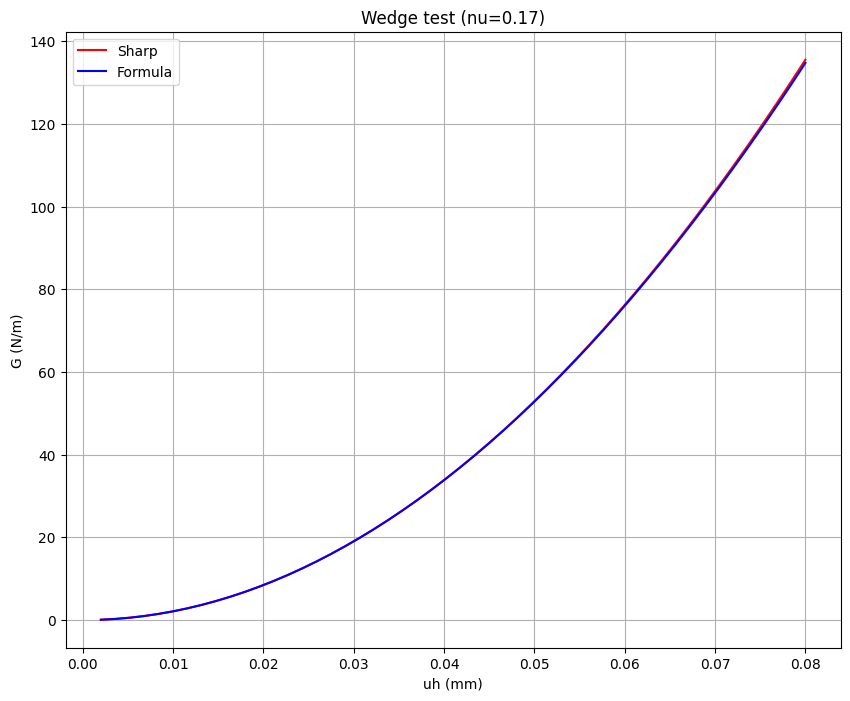

In [27]:
uh_wedge_nu17 = simulation_wedge.iloc[2:52, 16].to_numpy().astype(float)
G_wedge_nu17 = simulation_wedge.iloc[2:52, 17].to_numpy().astype(float)/1000
Ph_wedge_nu17 = simulation_wedge.iloc[2:52, 18].to_numpy().astype(float)*1000
G_wedge_nu17_fit = Gwedge((0.17, 25e3, uh_wedge_nu17), *popt_Gwedge)
plt.figure(figsize=(10, 8))
plt.plot(uh_wedge_nu17, G_wedge_nu17*1000, color='red', label='Sharp')
plt.plot(uh_wedge_nu17, G_wedge_nu17_fit*1000, color='blue', label='Formula')
plt.xlabel('uh (mm)')
plt.ylabel('G (N/m)')
plt.title('Wedge test (nu=0.17)')
plt.legend()
plt.grid()

In [28]:
uhback_wedge_experiment = simulation_wedge.iloc[2:5797, 25].to_numpy().astype(float)
uhfront_wedge_experiment = simulation_wedge.iloc[2:5797, 26].to_numpy().astype(float)
Pv_wedge_experiment = simulation_wedge.iloc[2:5797, 27].to_numpy().astype(float)*1000
uhback_wedge_experiment_smoothed = simple_moving_average(uhback_wedge_experiment, 50)
uhfront_wedge_experiment_smoothed = simple_moving_average(uhfront_wedge_experiment, 50)
Pv_wedge_experiment_smoothed = simple_moving_average(Pv_wedge_experiment, 50)

uh_wedge_pf = simulation_wedge.iloc[2:85, 0].to_numpy().astype(float)
Pv_wedge_pf = simulation_wedge.iloc[2:85, 2].to_numpy().astype(float)*1000

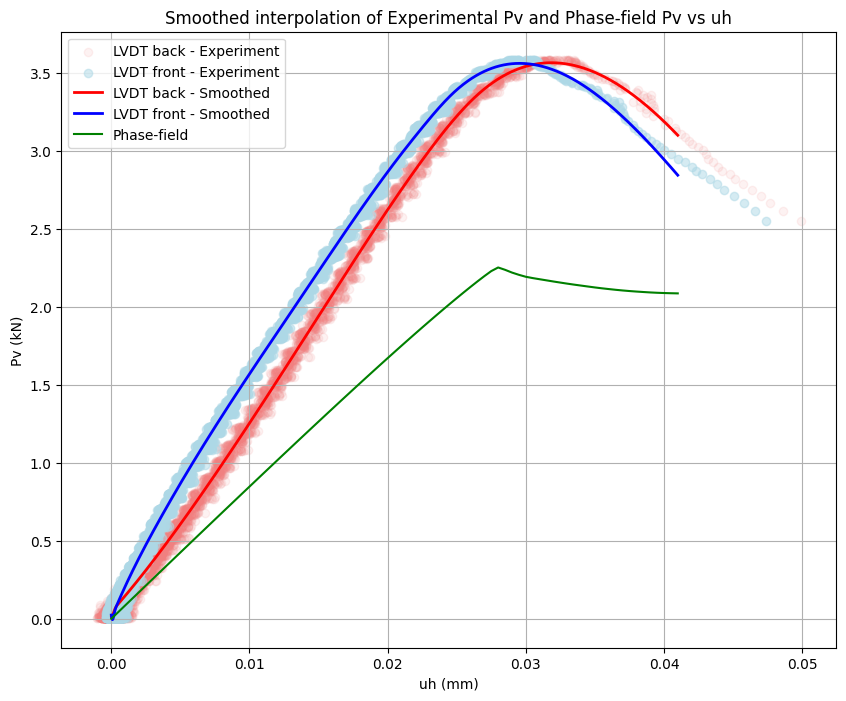

In [29]:
# 1) Clean + restrict domain
uhback_wedge_experiment_smoothed = np.asarray(uhback_wedge_experiment_smoothed, dtype=float)
uhfront_wedge_experiment_smoothed = np.asarray(uhfront_wedge_experiment_smoothed, dtype=float)
Pv_wedge_experiment_smoothed = np.asarray(Pv_wedge_experiment_smoothed, dtype=float)

mask = (
    np.isfinite(uhback_wedge_experiment_smoothed) & np.isfinite(uhfront_wedge_experiment_smoothed) & np.isfinite(Pv_wedge_experiment_smoothed) &
    (uhback_wedge_experiment_smoothed >= 0.0) & (uhback_wedge_experiment_smoothed <= np.max(uhback_wedge_experiment_smoothed))
)

uhback_wedge_experiment_smoothed = uhback_wedge_experiment_smoothed[mask]
uhfront_wedge_experiment_smoothed = uhfront_wedge_experiment_smoothed[mask]
Pv_wedge_experiment_smoothed = Pv_wedge_experiment_smoothed[mask]

# Guard against duplicate x values (required for spline fit)- uhback
order_back = np.argsort(uhback_wedge_experiment_smoothed)
uhback_wedge_experiment_smoothed = uhback_wedge_experiment_smoothed[order_back]
Pvback_wedge_experiment_smoothed = Pv_wedge_experiment_smoothed[order_back]
uhback_wedge_experiment_smoothed, idx = np.unique(uhback_wedge_experiment_smoothed, return_index=True)
Pvback_wedge_experiment_smoothed = Pvback_wedge_experiment_smoothed[idx]

order_front = np.argsort(uhfront_wedge_experiment_smoothed)
uhfront_wedge_experiment_smoothed = uhfront_wedge_experiment_smoothed[order_front]
Pvfront_wedge_experiment_smoothed = Pv_wedge_experiment_smoothed[order_front]
uhfront_wedge_experiment_smoothed, idx = np.unique(uhfront_wedge_experiment_smoothed, return_index=True)
Pvfront_wedge_experiment_smoothed = Pvfront_wedge_experiment_smoothed[idx]

# 2) Fit smoothing spline (s chosen from noise level)
# Larger s => smoother curve. This heuristic usually works for experimental-like data.
s = 0.0001 * len(uhback_wedge_experiment_smoothed) * np.nanvar(Pvback_wedge_experiment_smoothed)
spl_back = UnivariateSpline(uhback_wedge_experiment_smoothed, Pvback_wedge_experiment_smoothed, s=s)

s = 0.0001 * len(uhfront_wedge_experiment_smoothed) * np.nanvar(Pvfront_wedge_experiment_smoothed)
spl_front = UnivariateSpline(uhfront_wedge_experiment_smoothed, Pvfront_wedge_experiment_smoothed, s=s)

# 3) Evaluate interpolation + slope on a uniform grid
# uhback_wedge_experiment_smoothed = np.linspace(0.0, np.max(uhback_wedge_experiment_smoothed), 1000)
uhback_wedge_experiment_smoothed = np.linspace(0.0, 0.041, 1000)
Pvback_wedge_experiment_smoothed = spl_back(uhback_wedge_experiment_smoothed)
slope_back_wedge = spl_back.derivative(1)(uhback_wedge_experiment_smoothed[20:])

# uhfront_wedge_experiment_smoothed = np.linspace(0.0, np.max(uhfront_wedge_experiment_smoothed), 1000)
uhfront_wedge_experiment_smoothed = np.linspace(0.0, 0.041, 1000)
Pvfront_wedge_experiment_smoothed = spl_front(uhfront_wedge_experiment_smoothed)
slope_front_wedge = spl_front.derivative(1)(uhfront_wedge_experiment_smoothed[20:])

# # 4) Plots
# fig, ax = plt.subplots(1, 2, figsize=(20, 8), sharex=True)

# ax[0].scatter(uhback_wedge_experiment, Pv_wedge_experiment/1000, color="red", alpha=0.1, label="LVDT back")
# ax[0].scatter(uhfront_wedge_experiment, Pv_wedge_experiment/1000, color="blue", alpha=0.1, label="LVDT front")
# ax[0].plot(uhback_wedge_experiment_smoothed, Pvback_wedge_experiment_smoothed/1000, color="red", linewidth=2, label="LVDT back - Smoothed")
# ax[0].plot(uhfront_wedge_experiment_smoothed, Pvfront_wedge_experiment_smoothed/1000, color="blue", linewidth=2, label="LVDT front - Smoothed")
# ax[0].plot(uh_wedge_pf, Pv_wedge_pf/1000, color='green', label='Phase-field')
# ax[0].set_ylabel("Pv (kN)")
# ax[0].set_xlabel("uh (mm)")
# ax[0].set_title("Smoothed interpolation of Pv and Phase-field Pv vs uh")
# ax[0].grid(True)
# ax[0].legend()

# ax[1].plot(uhback_wedge_experiment_smoothed[20:], slope_back_wedge/1000, color="red", linewidth=2)
# ax[1].plot(uhfront_wedge_experiment_smoothed[20:], slope_front_wedge/1000, color="blue", linewidth=2)
# ax[1].plot(np.linspace(uhback_wedge_experiment_smoothed.min(), uhback_wedge_experiment_smoothed.max(), 10), 0.05*slope_back_wedge.max()/1000*np.ones(10), color="blue", linestyle="--", label="5% of max slope back")
# ax[1].plot(np.linspace(uhfront_wedge_experiment_smoothed.min(), uhfront_wedge_experiment_smoothed.max(), 10), 0.05*slope_front_wedge.max()/1000*np.ones(10), color="red", linestyle="--", label="5% of max slope front")
# ax[1].set_xlabel("uh (mm)")
# ax[1].set_ylabel("slope (kN/mm)")
# ax[1].set_title("Slope vs uh")
# ax[1].grid(True)
# ax[1].legend()

# plt.tight_layout()

plt.figure(figsize=(10, 8))
plt.scatter(uhback_wedge_experiment, Pv_wedge_experiment/1000, color="lightcoral", alpha=0.1, label="LVDT back - Experiment")
plt.scatter(uhfront_wedge_experiment, Pv_wedge_experiment/1000, color="lightblue", alpha=0.5, label="LVDT front - Experiment")
plt.plot(uhback_wedge_experiment_smoothed, Pvback_wedge_experiment_smoothed/1000, color="red", linewidth=2, label="LVDT back - Smoothed")
plt.plot(uhfront_wedge_experiment_smoothed, Pvfront_wedge_experiment_smoothed/1000, color="blue", linewidth=2, label="LVDT front - Smoothed")
plt.plot(uh_wedge_pf, Pv_wedge_pf/1000, color='green', label='Phase-field')
plt.xlabel("uh (mm)")
plt.ylabel("Pv (kN)")
plt.title("Smoothed interpolation of Experimental Pv and Phase-field Pv vs uh")
plt.grid(True)
plt.legend()

In [30]:
# uhback_wedge_experiment_smoothed_2000 = resample_to_n(uhback_wedge_experiment_smoothed, n=2000)
# uhfront_wedge_experiment_smoothed_2000 = resample_to_n(uhfront_wedge_experiment_smoothed, n=2000)
# Pvback_wedge_experiment_smoothed_2000 = resample_to_n(Pvback_wedge_experiment_smoothed, n=2000)
# Pvfront_wedge_experiment_smoothed_2000 = resample_to_n(Pvfront_wedge_experiment_smoothed, n=2000)

# # Save Wedge test data to an Excel file
# data_to_save_wedge = {
#     "uhback_wedge": (uhback_wedge_experiment_smoothed_2000, Pvback_wedge_experiment_smoothed_2000),
#     "uhfront_wedge": (uhfront_wedge_experiment_smoothed_2000, Pvfront_wedge_experiment_smoothed_2000),
# }
# out_path_wedge = "wedge_test_corrected_curves.xlsx"

# with pd.ExcelWriter(out_path_wedge, engine="xlsxwriter") as writer:
#     for sheet, (u, S) in data_to_save_wedge.items():
#         df_out = pd.DataFrame({"u_mm": np.asarray(u, dtype=float), "S_kN": np.asarray(S, dtype=float)})
#         df_out.to_excel(writer, sheet_name=sheet, index=False)

# print(f"Saved to {out_path_wedge}")

In [31]:
# # Find first uh where slope_wedge drops below 0.05 * max(slope_wedge)
# threshold = 0.0 * np.nanmax(slope_wedge)
# idx = np.flatnonzero(slope_wedge < threshold)

# uh_threshold = uh_wedge_experiment_smoothed[idx[0]] if idx.size else np.nan
# uh_threshold

In [32]:
uhback_wedge_experiment_smoothed[Pvback_wedge_experiment_smoothed.argmax()]

np.float64(0.03184784784784785)

In [33]:
Gwedge((0.17, 25e3, uhback_wedge_experiment_smoothed[Pvback_wedge_experiment_smoothed.argmax()]), *popt_Gwedge)*1000

np.float64(21.46259027960236)

In [34]:
uhfront_wedge_experiment_smoothed[Pvfront_wedge_experiment_smoothed.argmax()]

np.float64(0.029549549549549553)

In [35]:
Gwedge((0.17, 25e3, uhfront_wedge_experiment_smoothed[Pvfront_wedge_experiment_smoothed.argmax()]), *popt_Gwedge)*1000

np.float64(18.47920553131895)

In [36]:
uh_wedge_pf[Pv_wedge_pf.argmax()]

np.float64(0.028)

In [37]:
Gwedge((0.17, 25e3, uh_wedge_pf[Pv_wedge_pf.argmax()]), *popt_Gwedge)*1000

np.float64(16.593397023152605)

In [38]:
(uhfront_wedge_experiment_smoothed[Pvfront_wedge_experiment_smoothed.argmax()]+uhback_wedge_experiment_smoothed[Pvback_wedge_experiment_smoothed.argmax()])*0.5

np.float64(0.030698698698698703)

In [39]:
Gwedge((0.17, 25e3, (uhfront_wedge_experiment_smoothed[Pvfront_wedge_experiment_smoothed.argmax()]+uhback_wedge_experiment_smoothed[Pvback_wedge_experiment_smoothed.argmax()])*0.5), *popt_Gwedge)*1000

np.float64(19.94308086732506)

(0.0, 0.042)

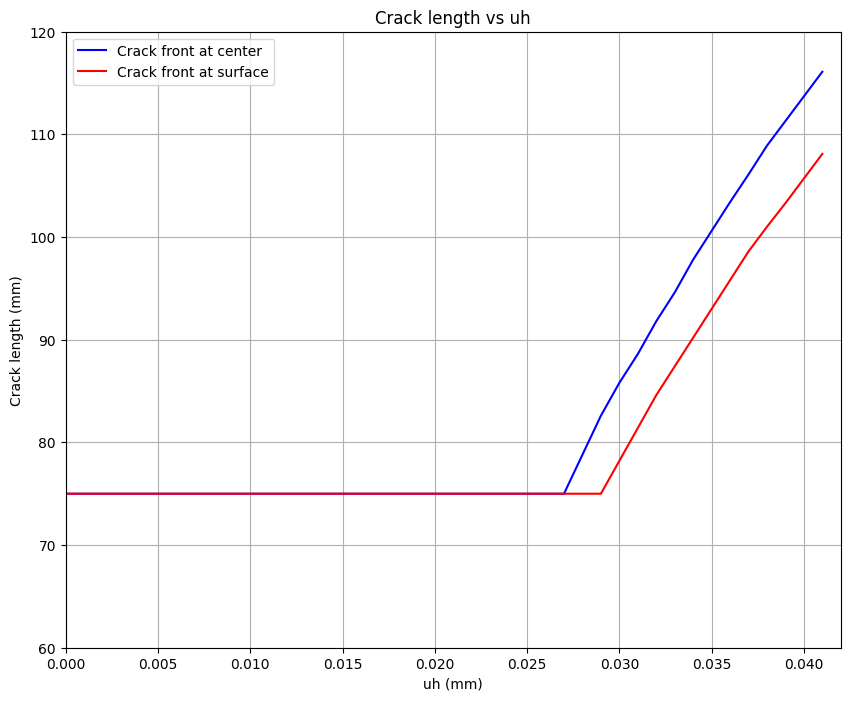

In [40]:
A_center = simulation_wedge.iloc[2:85, 3].to_numpy().astype(float)
A_surface = simulation_wedge.iloc[2:85, 4].to_numpy().astype(float)
mask = np.isfinite(uh_wedge_pf) & np.isfinite(A_center) & np.isfinite(A_surface)
plt.figure(figsize=(10, 8))
plt.plot(uh_wedge_pf[mask], A_center[mask], label='Crack front at center', color='blue')
plt.plot(uh_wedge_pf[mask], A_surface[mask], label='Crack front at surface', color='red')
plt.xlabel('uh (mm)')
plt.ylabel('Crack length (mm)')
plt.title('Crack length vs uh')
plt.legend()
plt.grid(True)
plt.ylim(60, 120)
plt.xlim(0, 0.042)

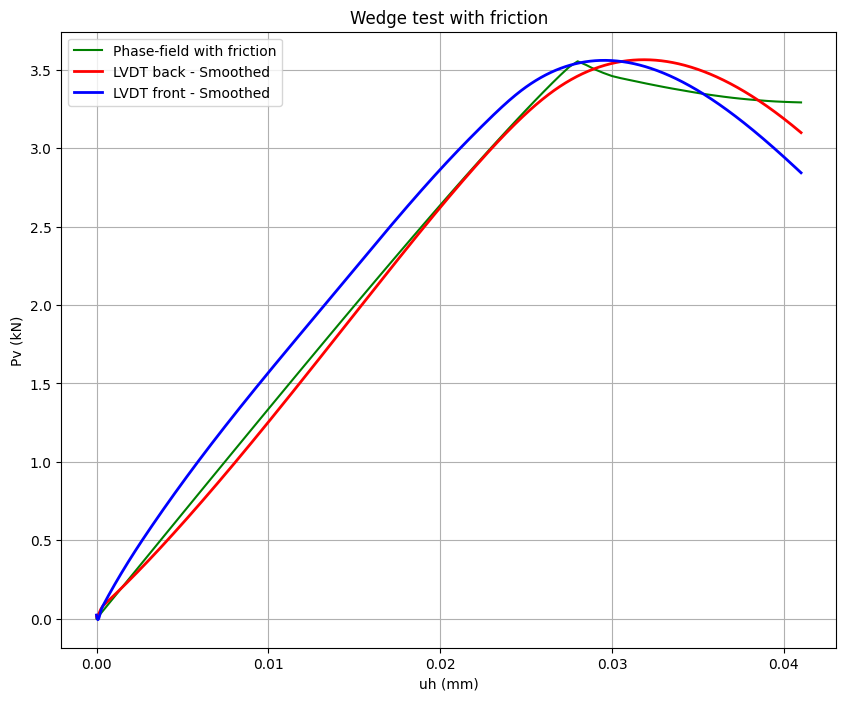

In [41]:
# Friction
fric_mu = 0.05
Pv_wedge_pf_5 = Pv_wedge_pf/np.tan(5*np.pi/180)*np.tan(5*np.pi/180 + np.arctan(fric_mu))
plt.figure(figsize=(10, 8))
plt.plot(uh_wedge_pf, Pv_wedge_pf_5/1000, label='Phase-field with friction', color='green')
plt.plot(uhback_wedge_experiment_smoothed, Pvback_wedge_experiment_smoothed/1000, color="red", linewidth=2, label="LVDT back - Smoothed")
plt.plot(uhfront_wedge_experiment_smoothed, Pvfront_wedge_experiment_smoothed/1000, color="blue", linewidth=2, label="LVDT front - Smoothed")
plt.xlabel('uh (mm)')
plt.ylabel('Pv (kN)')
plt.title('Wedge test with friction')
plt.legend()
plt.grid()

3 point bending

In [42]:
simulation_3pt = pd.read_excel('Testing_protocol_paper_results.xlsx', sheet_name='3pt-unnotched', header=None, na_filter=True)

In [43]:
u_3pt_pf = simulation_3pt.iloc[2:104, 0].to_numpy().astype(float)
S_3pt_pf = simulation_3pt.iloc[2:104, 1].to_numpy().astype(float)

u_3pt_exp1 = simulation_3pt.iloc[2:42369, 3].to_numpy().astype(float)
S_3pt_exp1 = simulation_3pt.iloc[2:42369, 4].to_numpy().astype(float)
u_3pt_exp2 = simulation_3pt.iloc[2:27954, 6].to_numpy().astype(float)
S_3pt_exp2 = simulation_3pt.iloc[2:27954, 7].to_numpy().astype(float)
u_3pt_exp3 = simulation_3pt.iloc[2:21565, 9].to_numpy().astype(float)
S_3pt_exp3 = simulation_3pt.iloc[2:21565, 10].to_numpy().astype(float)
u_3pt_exp4 = simulation_3pt.iloc[2:28834, 12].to_numpy().astype(float)
S_3pt_exp4 = simulation_3pt.iloc[2:28834, 13].to_numpy().astype(float)
u_3pt_exp5 = simulation_3pt.iloc[2:29102, 15].to_numpy().astype(float)
S_3pt_exp5 = simulation_3pt.iloc[2:29102, 16].to_numpy().astype(float)

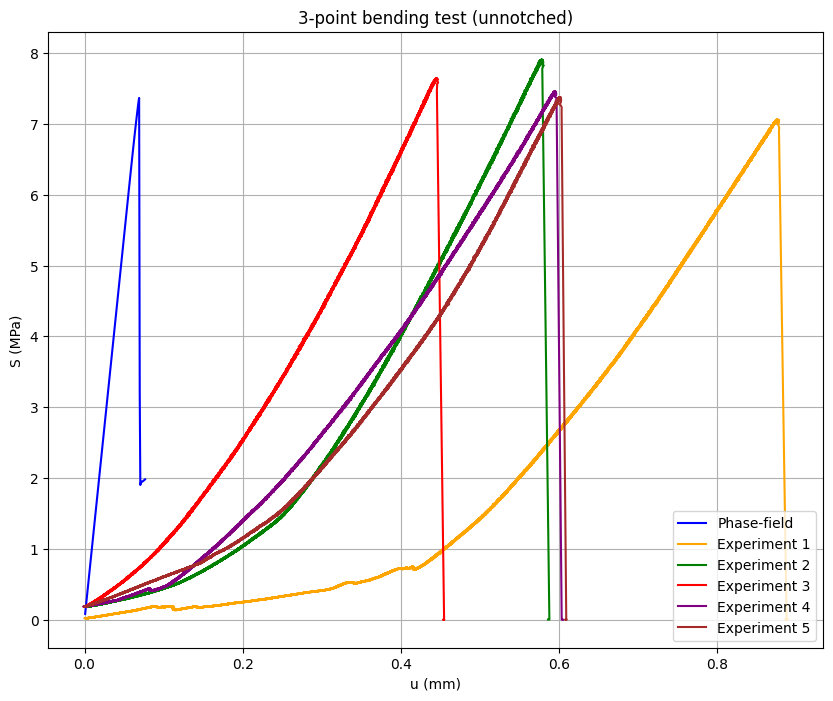

In [44]:
plt.figure(figsize=(10, 8))
plt.plot(u_3pt_pf, S_3pt_pf, label='Phase-field', color='blue')
plt.plot(u_3pt_exp1, S_3pt_exp1, label='Experiment 1', color='orange')
plt.plot(u_3pt_exp2, S_3pt_exp2, label='Experiment 2', color='green')
plt.plot(u_3pt_exp3, S_3pt_exp3, label='Experiment 3', color='red')
plt.plot(u_3pt_exp4, S_3pt_exp4, label='Experiment 4', color='purple')
plt.plot(u_3pt_exp5, S_3pt_exp5, label='Experiment 5', color='brown')
plt.xlabel('u (mm)')
plt.ylabel('S (MPa)')
plt.title('3-point bending test (unnotched)')
plt.grid()
plt.legend()

In [45]:
print(max(S_3pt_exp1), max(S_3pt_exp2), max(S_3pt_exp3), max(S_3pt_exp4), max(S_3pt_exp5))

7.060923078201422 7.9068122189811145 7.640802266849498 7.457392191139675 7.376061473226245


In [46]:
np.average([max(S_3pt_exp1), max(S_3pt_exp2), max(S_3pt_exp3), max(S_3pt_exp4), max(S_3pt_exp5)])

np.float64(7.488398245679591)

In [47]:
max(S_3pt_pf)

np.float64(7.367088883138919)

In [48]:
def compliance_bending(d_exp, P_exp, d_pf, P_pf, factor):
    d_pf_comp = np.asarray(d_pf, dtype=float)
    P_pf_comp = np.asarray(P_pf, dtype=float)
    d_pf_comp = d_pf[:np.where(P_pf == P_pf.max())[0][0]]
    P_pf_comp = P_pf[:np.where(P_pf == P_pf.max())[0][0]]
    d_exp_comp = np.asarray(d_exp, dtype=float)
    P_exp_comp = np.asarray(P_exp, dtype=float)
    mask = np.isfinite(d_exp_comp) & np.isfinite(P_exp_comp) 
    d_exp_comp = d_exp_comp[mask]
    P_exp_comp = P_exp_comp[mask]
    d_exp_comp = d_exp[:np.where(P_exp == P_exp.max())[0][0]]
    P_exp_comp = P_exp[:np.where(P_exp == P_exp.max())[0][0]]

    order = np.argsort(P_exp_comp)
    d_exp_comp = d_exp_comp[order]
    P_exp_comp = P_exp_comp[order]
    P_exp_comp, idx = np.unique(P_exp_comp, return_index=True)
    d_exp_comp = d_exp_comp[idx]

    s = 0.01 * len(P_exp_comp) * np.nanvar(d_exp_comp)
    spl_exp = UnivariateSpline(P_exp_comp, d_exp_comp, s=s)

    order = np.argsort(P_pf_comp)
    d_pf_comp = d_pf_comp[order]
    P_pf_comp = P_pf_comp[order]
    P_pf_comp, idx = np.unique(P_pf_comp, return_index=True)
    d_pf_comp = d_pf_comp[idx]

    s = 5 * len(P_pf_comp) * np.nanvar(d_pf_comp)
    spl_pf = UnivariateSpline(P_pf_comp, d_pf_comp, s=s)

    P_machine = np.linspace(0, 5, 100)
    d_machine = spl_exp(P_machine) - spl_pf(P_machine)

    order = np.argsort(P_machine)
    P_machine = P_machine[order]
    d_machine = d_machine[order]
    P_machine, idx = np.unique(P_machine, return_index=True)
    d_machine = d_machine[idx]

    s = 0.01 * len(P_machine) * np.nanvar(d_machine)
    spl_machine = UnivariateSpline(P_machine, d_machine, s=s)

    # d_exp_actual = np.zeros_like(d_exp_comp)
    # for i, P in enumerate(P_exp_comp):
    #     if P < 3:
    #         d_exp_actual[i] = spl_exp(P) - spl_machine(P)
    #     else:
    #         d_exp_actual[i] = spl_exp(P) - spl_machine(P)*((P-3)/(P_exp_comp.max()-3)*(0.8-1)+1)  # Extrapolate beyond 3 kN
    d_exp_actual = spl_exp(P_exp_comp) - spl_machine(P_exp_comp)*factor
    d_exp_actual = np.array([0, *d_exp_actual, d_exp_actual[-1] + (d_exp_comp[-1] - d_exp_comp[-2])])  # Extrapolate last point
    P_exp_actual = P_exp_comp
    P_exp_actual = np.array([0, *P_exp_actual, 0])  # Extrapolate last point
    return spl_machine, spl_exp, d_exp_actual, P_exp_actual

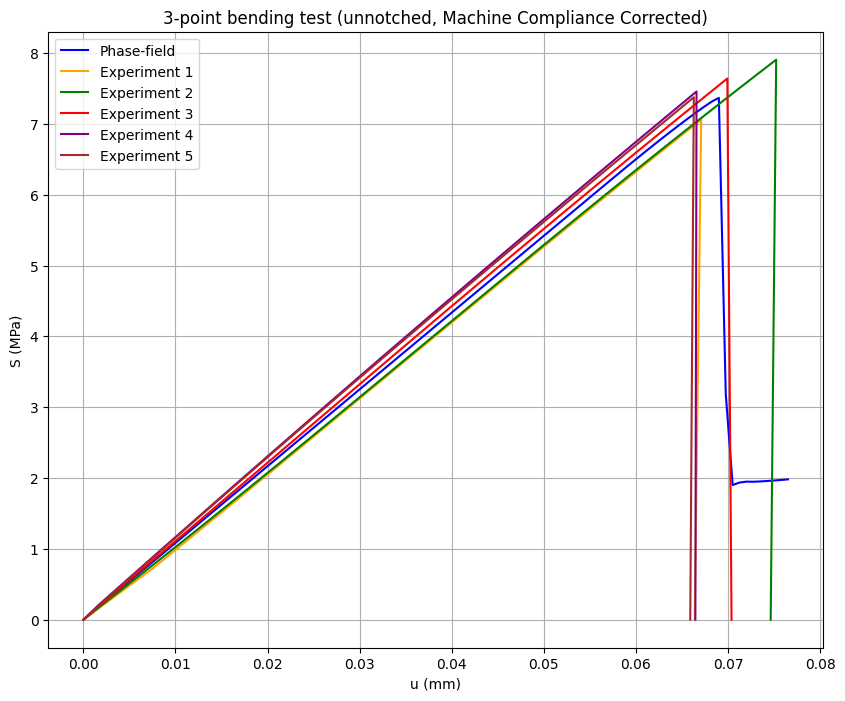

In [49]:
spl_machine1_3pt, spl_exp1_3pt, u_3pt_exp1_actual, S_3pt_exp1_actual = compliance_bending(u_3pt_exp1[20000:], S_3pt_exp1[20000:], u_3pt_pf, S_3pt_pf, 0.998)
spl_machine2_3pt, spl_exp_3pt, u_3pt_exp2_actual, S_3pt_exp2_actual = compliance_bending(u_3pt_exp2, S_3pt_exp2, u_3pt_pf, S_3pt_pf, 0.997)
spl_machine3_3pt, spl_exp3_3pt, u_3pt_exp3_actual, S_3pt_exp3_actual = compliance_bending(u_3pt_exp3, S_3pt_exp3, u_3pt_pf, S_3pt_pf, 1.003)
spl_machine4_3pt, spl_exp4_3pt, u_3pt_exp4_actual, S_3pt_exp4_actual = compliance_bending(u_3pt_exp4, S_3pt_exp4, u_3pt_pf, S_3pt_pf, 1.005)
spl_machine5_3pt, spl_exp5_3pt, u_3pt_exp5_actual, S_3pt_exp5_actual = compliance_bending(u_3pt_exp5, S_3pt_exp5, u_3pt_pf, S_3pt_pf, 1.004)


plt.figure(figsize=(10, 8))
plt.plot(u_3pt_pf, S_3pt_pf, label='Phase-field', color='blue')
plt.plot(u_3pt_exp1_actual, S_3pt_exp1_actual, label='Experiment 1', color='orange')
plt.plot(u_3pt_exp2_actual, S_3pt_exp2_actual, label='Experiment 2', color='green')
plt.plot(u_3pt_exp3_actual, S_3pt_exp3_actual, label='Experiment 3', color='red')
plt.plot(u_3pt_exp4_actual, S_3pt_exp4_actual, label='Experiment 4', color='purple')
plt.plot(u_3pt_exp5_actual, S_3pt_exp5_actual, label='Experiment 5', color='brown')
plt.xlabel('u (mm)')
plt.ylabel('S (MPa)')
plt.title('3-point bending test (unnotched, Machine Compliance Corrected)')
plt.grid()
plt.legend()

In [50]:
# u_3pt_exp1_actual_2000 = resample_to_n(u_3pt_exp1_actual, n=2000)
# S_3pt_exp1_actual_2000 = resample_to_n(S_3pt_exp1_actual, n=2000)
# u_3pt_exp2_actual_2000 = resample_to_n(u_3pt_exp2_actual, n=2000)
# S_3pt_exp2_actual_2000 = resample_to_n(S_3pt_exp2_actual, n=2000)
# u_3pt_exp3_actual_2000 = resample_to_n(u_3pt_exp3_actual, n=2000)
# S_3pt_exp3_actual_2000 = resample_to_n(S_3pt_exp3_actual, n=2000)
# u_3pt_exp4_actual_2000 = resample_to_n(u_3pt_exp4_actual, n=2000)
# S_3pt_exp4_actual_2000 = resample_to_n(S_3pt_exp4_actual, n=2000)
# u_3pt_exp5_actual_2000 = resample_to_n(u_3pt_exp5_actual, n=2000)
# S_3pt_exp5_actual_2000 = resample_to_n(S_3pt_exp5_actual, n=2000)

# # Save 3-point bending test data to an Excel file
# data_to_save_3pt = {
#     "3pt_exp1": (u_3pt_exp1_actual_2000, S_3pt_exp1_actual_2000),
#     "3pt_exp2": (u_3pt_exp2_actual_2000, S_3pt_exp2_actual_2000),
#     "3pt_exp3": (u_3pt_exp3_actual_2000, S_3pt_exp3_actual_2000),
#     "3pt_exp4": (u_3pt_exp4_actual_2000, S_3pt_exp4_actual_2000),
#     "3pt_exp5": (u_3pt_exp5_actual_2000, S_3pt_exp5_actual_2000),
# }

# out_path_3pt = "3pt_bending_test_corrected_curves.xlsx"

# with pd.ExcelWriter(out_path_3pt, engine="xlsxwriter") as writer:
#     for sheet, (u, S) in data_to_save_3pt.items():
#         df_out = pd.DataFrame({"u_mm": np.asarray(u, dtype=float), "S_kN": np.asarray(S, dtype=float)})
#         df_out.to_excel(writer, sheet_name=sheet, index=False)

# print(f"Saved to {out_path_3pt}")

4 point bending

In [51]:
simulation_4pt = pd.read_excel('Testing_protocol_paper_results.xlsx', sheet_name='4-pt', header=None, na_filter=True)

In [52]:
u_4pt_pf = simulation_4pt.iloc[2:99, 0].to_numpy().astype(float)
S_4pt_pf = simulation_4pt.iloc[2:99, 1].to_numpy().astype(float)

u_4pt_exp1 = simulation_4pt.iloc[2:5252, 3].to_numpy().astype(float)
S_4pt_exp1 = simulation_4pt.iloc[2:5252, 4].to_numpy().astype(float)
u_4pt_exp2 = simulation_4pt.iloc[2:5278, 6].to_numpy().astype(float)
S_4pt_exp2 = simulation_4pt.iloc[2:5278, 7].to_numpy().astype(float)
u_4pt_exp3 = simulation_4pt.iloc[2:6152, 9].to_numpy().astype(float)
S_4pt_exp3 = simulation_4pt.iloc[2:6152, 10].to_numpy().astype(float)
u_4pt_exp4 = simulation_4pt.iloc[2:5943, 12].to_numpy().astype(float)
S_4pt_exp4 = simulation_4pt.iloc[2:5943, 13].to_numpy().astype(float)

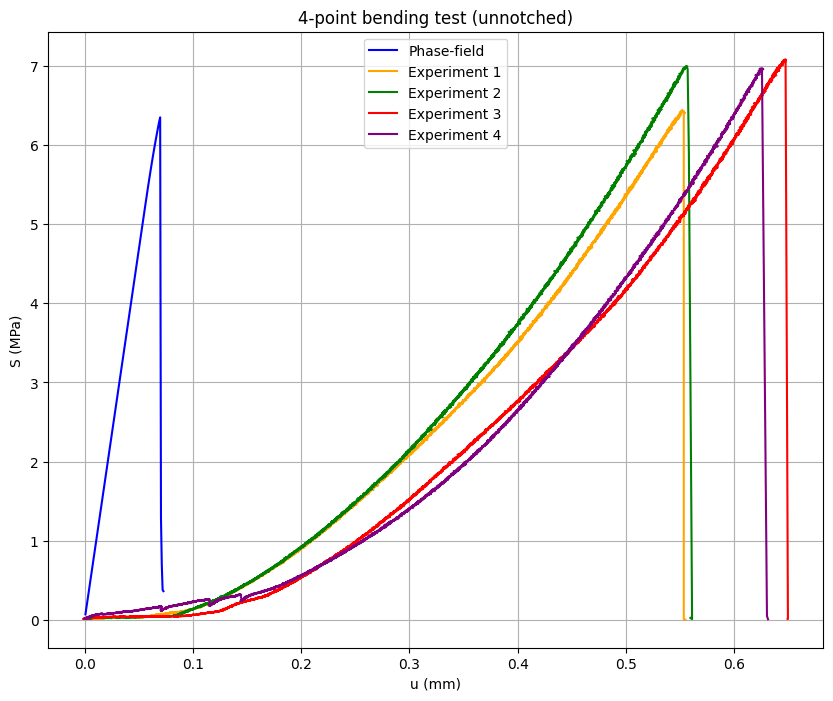

In [53]:
plt.figure(figsize=(10, 8))
plt.plot(u_4pt_pf, S_4pt_pf, label='Phase-field', color='blue')
plt.plot(u_4pt_exp1, S_4pt_exp1, label='Experiment 1', color='orange')
plt.plot(u_4pt_exp2, S_4pt_exp2, label='Experiment 2', color='green')
plt.plot(u_4pt_exp3, S_4pt_exp3, label='Experiment 3', color='red')
plt.plot(u_4pt_exp4, S_4pt_exp4, label='Experiment 4', color='purple')
plt.xlabel('u (mm)')
plt.ylabel('S (MPa)')
plt.title('4-point bending test (unnotched)')
plt.grid()
plt.legend()

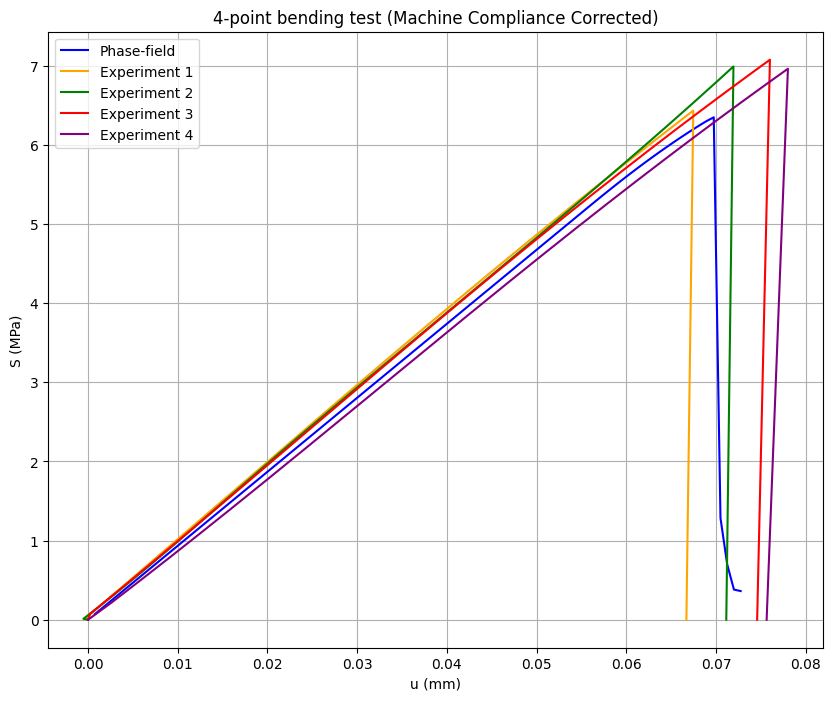

In [54]:
spl_machine1_4pt, spl_exp1_4pt, u_4pt_exp1_actual, S_4pt_exp1_actual = compliance_bending(u_4pt_exp1, S_4pt_exp1, u_4pt_pf, S_4pt_pf, 1.005)
spl_machine2_4pt, spl_exp2_4pt, u_4pt_exp2_actual, S_4pt_exp2_actual = compliance_bending(u_4pt_exp2, S_4pt_exp2, u_4pt_pf, S_4pt_pf, 1.004)
spl_machine3_4pt, spl_exp3_4pt, u_4pt_exp3_actual, S_4pt_exp3_actual = compliance_bending(u_4pt_exp3[1000:], S_4pt_exp3[1000:], u_4pt_pf, S_4pt_pf, 1.003)
spl_machine4_4pt, spl_exp4_4pt, u_4pt_exp4_actual, S_4pt_exp4_actual = compliance_bending(u_4pt_exp4[1000:], S_4pt_exp4[1000:], u_4pt_pf, S_4pt_pf, 0.997)

plt.figure(figsize=(10, 8))
plt.plot(u_4pt_pf, S_4pt_pf, label='Phase-field', color='blue')
plt.plot(u_4pt_exp1_actual, S_4pt_exp1_actual, label='Experiment 1', color='orange')
plt.plot(u_4pt_exp2_actual, S_4pt_exp2_actual, label='Experiment 2', color='green')
plt.plot(u_4pt_exp3_actual, S_4pt_exp3_actual, label='Experiment 3', color='red')
plt.plot(u_4pt_exp4_actual, S_4pt_exp4_actual, label='Experiment 4', color='purple')
plt.xlabel('u (mm)')
plt.ylabel('S (MPa)')
plt.title('4-point bending test (Machine Compliance Corrected)')
plt.grid()
plt.legend()

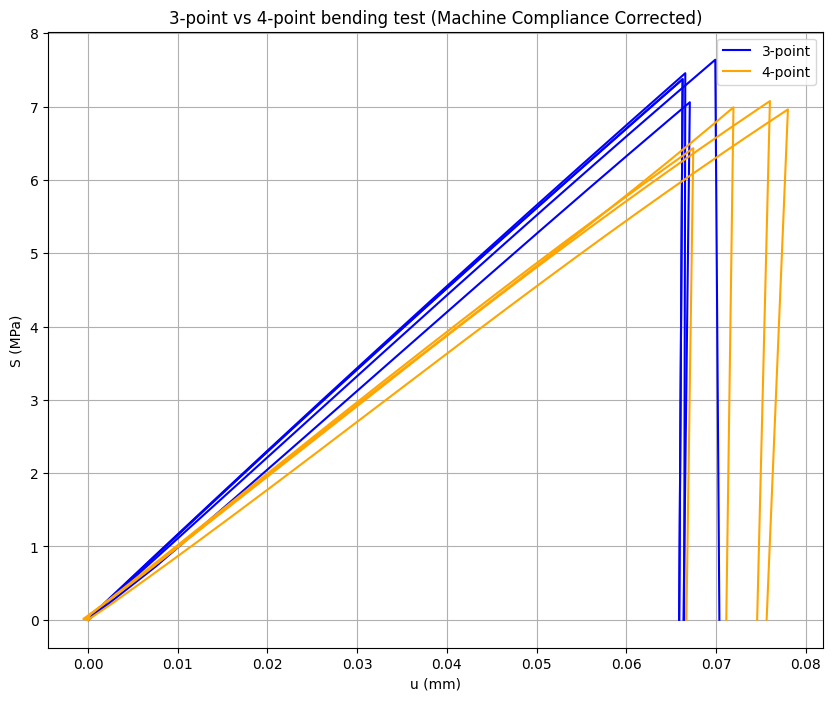

In [55]:
plt.figure(figsize=(10, 8))
plt.plot(u_3pt_exp1_actual, S_3pt_exp1_actual, label='3-point', color='blue')
plt.plot(u_3pt_exp3_actual, S_3pt_exp3_actual,  color='blue')
plt.plot(u_3pt_exp4_actual, S_3pt_exp4_actual,  color='blue')
plt.plot(u_3pt_exp5_actual, S_3pt_exp5_actual,  color='blue')
plt.plot(u_3pt_exp5_actual, S_3pt_exp5_actual,  color='blue')
plt.plot(u_4pt_exp1_actual, S_4pt_exp1_actual, label='4-point', color='orange')
plt.plot(u_4pt_exp2_actual, S_4pt_exp2_actual, color='orange')
plt.plot(u_4pt_exp3_actual, S_4pt_exp3_actual, color='orange')
plt.plot(u_4pt_exp4_actual, S_4pt_exp4_actual, color='orange')
plt.xlabel('u (mm)')
plt.ylabel('S (MPa)')
plt.title('3-point vs 4-point bending test (Machine Compliance Corrected)')
plt.grid()
plt.legend()

In [56]:
# u_4pt_exp1_actual_2000 = resample_to_n(u_4pt_exp1_actual, n=2000)
# S_4pt_exp1_actual_2000 = resample_to_n(S_4pt_exp1_actual, n=2000)
# u_4pt_exp2_actual_2000 = resample_to_n(u_4pt_exp2_actual, n=2000)
# S_4pt_exp2_actual_2000 = resample_to_n(S_4pt_exp2_actual, n=2000)
# u_4pt_exp3_actual_2000 = resample_to_n(u_4pt_exp3_actual, n=2000)
# S_4pt_exp3_actual_2000 = resample_to_n(S_4pt_exp3_actual, n=2000)
# u_4pt_exp4_actual_2000 = resample_to_n(u_4pt_exp4_actual, n=2000)
# S_4pt_exp4_actual_2000 = resample_to_n(S_4pt_exp4_actual, n=2000)

# # Save 4-point bending test data to an Excel file
# data_to_save_4pt = {
#     "4pt_exp1": (u_4pt_exp1_actual_2000, S_4pt_exp1_actual_2000),
#     "4pt_exp2": (u_4pt_exp2_actual_2000, S_4pt_exp2_actual_2000),
#     "4pt_exp3": (u_4pt_exp3_actual_2000, S_4pt_exp3_actual_2000),
#     "4pt_exp4": (u_4pt_exp4_actual_2000, S_4pt_exp4_actual_2000),
# }

# out_path_4pt = "4pt_bending_test_corrected_curves.xlsx"

# with pd.ExcelWriter(out_path_4pt, engine="xlsxwriter") as writer:
#     for sheet, (u, S) in data_to_save_4pt.items():
#         df_out = pd.DataFrame({"u_mm": np.asarray(u, dtype=float), "S_kN": np.asarray(S, dtype=float)})
#         df_out.to_excel(writer, sheet_name=sheet, index=False)

# print(f"Saved to {out_path_4pt}")

3 point bending - notched

In [57]:
simulation_3pt_notched = pd.read_excel('Testing_protocol_paper_results.xlsx', sheet_name='3pt-notched', header=None, na_filter=True)

In [58]:
u_3ptnotched_pf = simulation_3pt_notched.iloc[2:84, 0].to_numpy().astype(float)
P_3ptnotched_pf = simulation_3pt_notched.iloc[2:84, 1].to_numpy().astype(float)

u_3ptnotched_exp1 = simulation_3pt_notched.iloc[2:11403, 3].to_numpy().astype(float)
P_3ptnotched_exp1 = simulation_3pt_notched.iloc[2:11403, 4].to_numpy().astype(float)
u_3ptnotched_exp2 = simulation_3pt_notched.iloc[2:13633, 6].to_numpy().astype(float)
P_3ptnotched_exp2 = simulation_3pt_notched.iloc[2:13633, 7].to_numpy().astype(float)
u_3ptnotched_exp3 = simulation_3pt_notched.iloc[2:14750, 9].to_numpy().astype(float)
P_3ptnotched_exp3 = simulation_3pt_notched.iloc[2:14750, 10].to_numpy().astype(float)

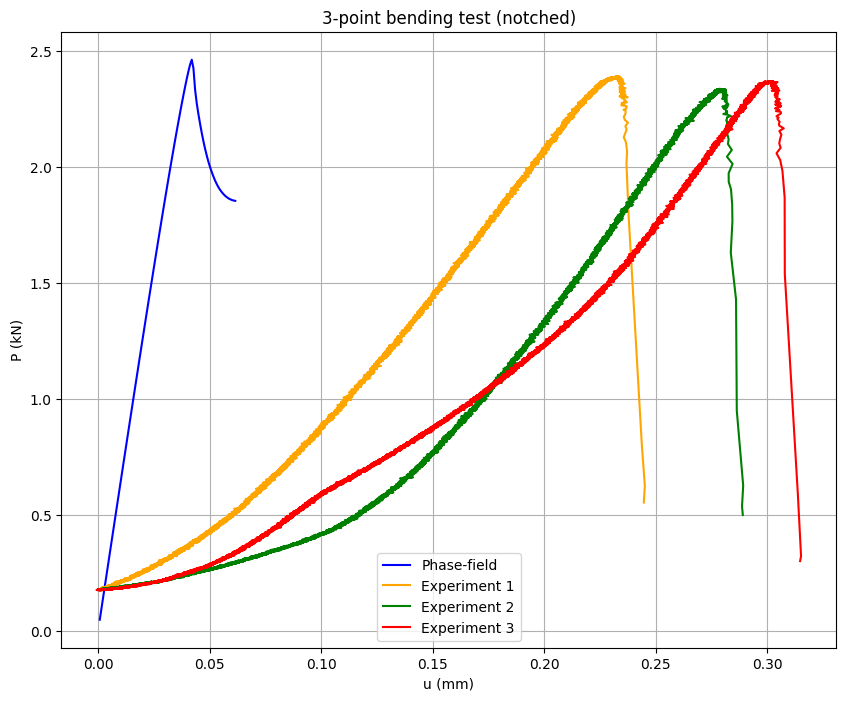

In [59]:
plt.figure(figsize=(10, 8))
plt.plot(u_3ptnotched_pf, P_3ptnotched_pf, label='Phase-field', color='blue')
plt.plot(u_3ptnotched_exp1, P_3ptnotched_exp1, label='Experiment 1', color='orange')
plt.plot(u_3ptnotched_exp2, P_3ptnotched_exp2, label='Experiment 2', color='green')
plt.plot(u_3ptnotched_exp3, P_3ptnotched_exp3, label='Experiment 3', color='red')
plt.xlabel('u (mm)')    
plt.ylabel('P (kN)')
plt.title('3-point bending test (notched)') 
plt.grid()
plt.legend()

In [60]:
def smoothen_exp(x, y, *,
                                x_min=0.0,
                                n_grid=200,
                                s_factor=1e-5,
                                enforce_monotonic_to_peak=True,
                                uniform_grid=True):
    """
    Smooth y(x) with UnivariateSpline using the same pattern as in your cell:
      - clean finite values, optionally restrict x>=x_min
      - sort by x, remove duplicate x
      - fit smoothing spline with s = s_factor * N * var(y)
      - evaluate on a uniform x-grid (or original x if uniform_grid=False)
      - optionally enforce non-decreasing up to the peak
    Returns: x_smooth, y_smooth, spline
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x >= x_min)
    x = x[mask]
    y = y[mask]

    if x.size < 4:
        raise ValueError("Not enough valid points to fit a spline.")

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    x, idx = np.unique(x, return_index=True)
    y = y[idx]

    s = float(s_factor) * len(x) * np.nanvar(y)
    spl = UnivariateSpline(x, y, s=s)

    if uniform_grid:
        x_s = np.linspace(x.min(), x.max(), int(n_grid))
    else:
        x_s = x.copy()

    y_s = spl(x_s)

    if enforce_monotonic_to_peak and y_s.size:
        imax = int(np.nanargmax(y_s))
        y_s[:imax + 1] = np.maximum.accumulate(y_s[:imax + 1])

    return x_s, y_s

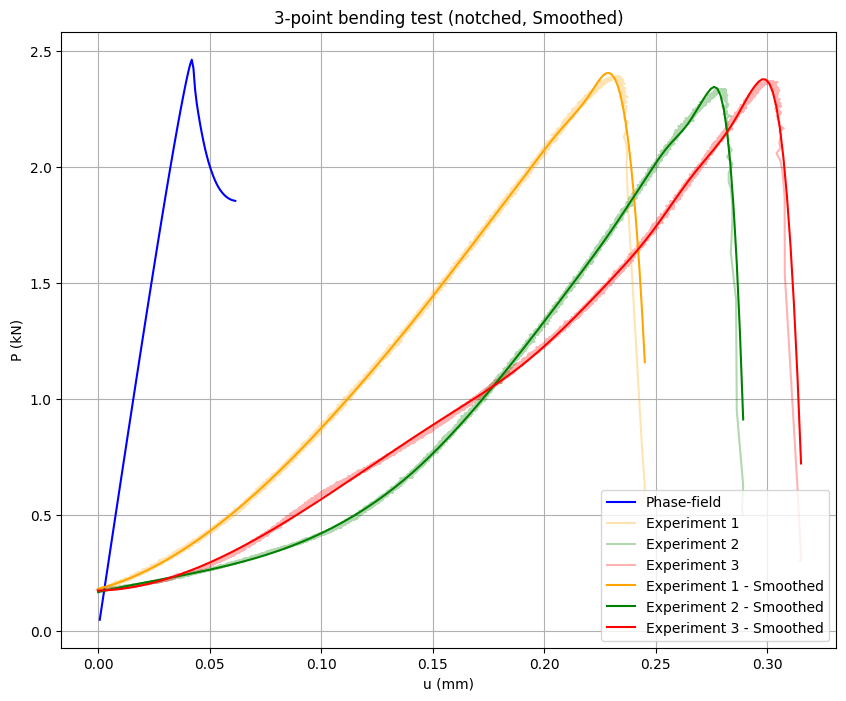

In [71]:
u_3ptnotched_exp1_smoothed, P_3ptnotched_exp1_smoothed = smoothen_exp(u_3ptnotched_exp1, P_3ptnotched_exp1, s_factor=0.0005)
u_3ptnotched_exp2_smoothed, P_3ptnotched_exp2_smoothed = smoothen_exp(u_3ptnotched_exp2, P_3ptnotched_exp2, s_factor=0.0005)
u_3ptnotched_exp3_smoothed, P_3ptnotched_exp3_smoothed = smoothen_exp(u_3ptnotched_exp3, P_3ptnotched_exp3, s_factor=0.0005)

plt.figure(figsize=(10, 8))
plt.plot(u_3ptnotched_pf, P_3ptnotched_pf, label='Phase-field', color='blue')
plt.plot(u_3ptnotched_exp1, P_3ptnotched_exp1, label='Experiment 1', color='orange', alpha=0.3)
plt.plot(u_3ptnotched_exp2, P_3ptnotched_exp2, label='Experiment 2', color='green', alpha=0.3)
plt.plot(u_3ptnotched_exp3, P_3ptnotched_exp3, label='Experiment 3', color='red', alpha=0.3)
plt.plot(u_3ptnotched_exp1_smoothed, P_3ptnotched_exp1_smoothed, label='Experiment 1 - Smoothed', color='orange')
plt.plot(u_3ptnotched_exp2_smoothed, P_3ptnotched_exp2_smoothed, label='Experiment 2 - Smoothed', color='green')
plt.plot(u_3ptnotched_exp3_smoothed, P_3ptnotched_exp3_smoothed, label='Experiment 3 - Smoothed', color='red')
plt.xlabel('u (mm)')
plt.ylabel('P (kN)')
plt.title('3-point bending test (notched, Smoothed)')
plt.grid()
plt.legend()

In [72]:
def compliance_bending_notched(d_exp, P_exp, d_pf, P_pf, factor1, factor2):
    d_pf_comp = np.asarray(d_pf, dtype=float)
    P_pf_comp = np.asarray(P_pf, dtype=float)
    d_pf_comp = d_pf[:np.where(P_pf == P_pf.max())[0][0]]
    P_pf_comp = P_pf[:np.where(P_pf == P_pf.max())[0][0]]
    d_exp_comp = np.asarray(d_exp, dtype=float)
    P_exp_comp = np.asarray(P_exp, dtype=float)
    mask = np.isfinite(d_exp_comp) & np.isfinite(P_exp_comp) 
    d_exp_comp = d_exp_comp[mask]
    P_exp_comp = P_exp_comp[mask]
    d_exp_comp = d_exp[:np.where(P_exp == P_exp.max())[0][0]]
    P_exp_comp = P_exp[:np.where(P_exp == P_exp.max())[0][0]]

    order = np.argsort(P_exp_comp)
    d_exp_comp = d_exp_comp[order]
    P_exp_comp = P_exp_comp[order]
    P_exp_comp, idx = np.unique(P_exp_comp, return_index=True)
    d_exp_comp = d_exp_comp[idx]

    s = 0.01 * len(P_exp_comp) * np.nanvar(d_exp_comp)
    spl_exp = UnivariateSpline(P_exp_comp, d_exp_comp, s=s)

    order = np.argsort(P_pf_comp)
    d_pf_comp = d_pf_comp[order]
    P_pf_comp = P_pf_comp[order]
    P_pf_comp, idx = np.unique(P_pf_comp, return_index=True)
    d_pf_comp = d_pf_comp[idx]

    s = 5 * len(P_pf_comp) * np.nanvar(d_pf_comp)
    spl_pf = UnivariateSpline(P_pf_comp, d_pf_comp, s=s)

    P_machine = np.linspace(0, 5, 100)
    d_machine = spl_exp(P_machine) - spl_pf(P_machine)

    order = np.argsort(P_machine)
    P_machine = P_machine[order]
    d_machine = d_machine[order]
    P_machine, idx = np.unique(P_machine, return_index=True)
    d_machine = d_machine[idx]

    s = 0.01 * len(P_machine) * np.nanvar(d_machine)
    spl_machine = UnivariateSpline(P_machine, d_machine, s=s)

    d_exp_actual = spl_exp(P_exp_comp) - spl_machine(P_exp_comp)*factor1
    d_exp_rest = d_exp[np.where(P_exp == P_exp.max())[0][0]:] 
    P_exp_rest = P_exp[np.where(P_exp == P_exp.max())[0][0]:]
    d_exp_actual = np.concatenate([d_exp_actual, d_exp_rest - spl_machine(P_exp_comp.max())*factor2])
    d_exp_actual = np.array([0, *d_exp_actual])  # Extrapolate last point
    P_exp_actual = P_exp_comp
    P_exp_actual = np.concatenate([[0], P_exp_actual, P_exp_rest])  # Extrapolate last point

    return spl_machine, spl_exp, d_exp_actual, P_exp_actual
    # return d_exp_smoothed, P_exp_smoothed, spl_machine

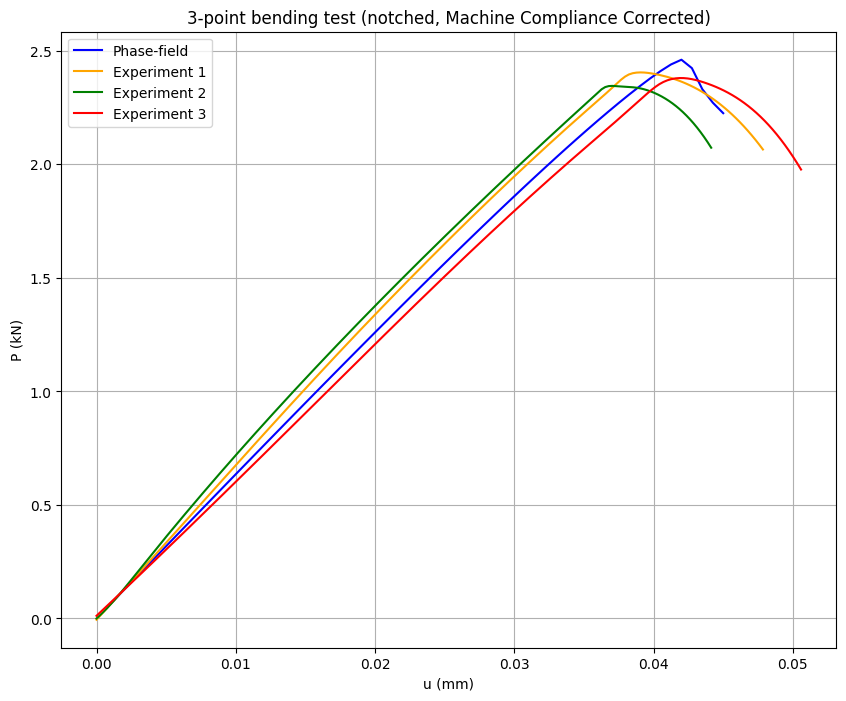

In [129]:
spl_machine1_3pt_notched, spl_exp1_3pt_notched, u_3ptnotched_exp1_actual, P_3ptnotched_exp1_actual = compliance_bending_notched(u_3ptnotched_exp1_smoothed, P_3ptnotched_exp1_smoothed, u_3ptnotched_pf, P_3ptnotched_pf, 1.01, 1.0)
spl_machine2_3pt_notched, spl_exp2_3pt_notched, u_3ptnotched_exp2_actual, P_3ptnotched_exp2_actual = compliance_bending_notched(u_3ptnotched_exp2_smoothed, P_3ptnotched_exp2_smoothed, u_3ptnotched_pf, P_3ptnotched_pf, 1.01, 0.955)
spl_machine3_3pt_notched, spl_exp3_3pt_notched, u_3ptnotched_exp3_actual, P_3ptnotched_exp3_actual = compliance_bending_notched(u_3ptnotched_exp3_smoothed, P_3ptnotched_exp3_smoothed, u_3ptnotched_pf, P_3ptnotched_pf, 0.995, 0.9999)
u_3ptnotched_exp1_actual, P_3ptnotched_exp1_actual = smoothen_exp(u_3ptnotched_exp1_actual, P_3ptnotched_exp1_actual, s_factor=0.000001)
u_3ptnotched_exp2_actual, P_3ptnotched_exp2_actual = smoothen_exp(u_3ptnotched_exp2_actual, P_3ptnotched_exp2_actual, s_factor=0.00000001)
u_3ptnotched_exp3_actual, P_3ptnotched_exp3_actual = smoothen_exp(u_3ptnotched_exp3_actual, P_3ptnotched_exp3_actual, s_factor=0.00001)

plt.figure(figsize=(10, 8))
plt.plot(u_3ptnotched_pf[:60], P_3ptnotched_pf[:60], label='Phase-field', color='blue')
# plt.scatter(u_3ptnotched_pf, P_3ptnotched_pf, color='blue', s=20)
plt.plot(u_3ptnotched_exp1_actual[:175], P_3ptnotched_exp1_actual[:175], label='Experiment 1', color='orange')
plt.plot(u_3ptnotched_exp2_actual[:175], P_3ptnotched_exp2_actual[:175], label='Experiment 2', color='green')
plt.plot(u_3ptnotched_exp3_actual[:175], P_3ptnotched_exp3_actual[:175], label='Experiment 3', color='red')
plt.xlabel('u (mm)')
plt.ylabel('P (kN)')
plt.title('3-point bending test (notched, Machine Compliance Corrected)')
plt.grid()
plt.legend()
# plt.xlim(0, 0.044)

In [118]:
# Save 3-point bending test (notched) data to an Excel file
data_to_save_3pt_notched = {
    "3 pt exp1": (u_3ptnotched_exp1_actual, P_3ptnotched_exp1_actual),
    "3 pt exp2": (u_3ptnotched_exp2_actual, P_3ptnotched_exp2_actual),
    "3 pt exp3": (u_3ptnotched_exp3_actual, P_3ptnotched_exp3_actual),
}

out_path_3pt_notched = "3pt_bending_test_notched_corrected_curves.xlsx"
with pd.ExcelWriter(out_path_3pt_notched, engine="xlsxwriter") as writer:
    for sheet, (u, P) in data_to_save_3pt_notched.items():
        df_out = pd.DataFrame({"u_mm": np.asarray(u, dtype=float), "P_kN": np.asarray(P, dtype=float)})
        df_out.to_excel(writer, sheet_name=sheet, index=False)